### Qiskit

In [1]:
import sympy as sp
from sympy.logic import SOPform
from qiskit.circuit.library import PhaseOracle, BitFlipOracleGate
from qiskit import QuantumCircuit

In [2]:
t_cost_list =[0,0,7,16,24,62,80,200,216,272,392,448,504,560,616,672,728]

def calc_tcost(circ):
    cost = 0
    for gate in circ.data:
        # Consider only multi-controlled gates
        ctrl_num = len(gate.qubits) - 1
        assert(ctrl_num<16)
        cost += t_cost_list[ctrl_num]
    # cost += circ.count_ops().get('t',0)
    # cost += circ.count_ops().get('tdg',0)
    return cost

In [3]:
def read_rand_tt(file_path):
    with open(file_path, 'r') as f:
        lines = f.readlines()
        # Each line is of the form truth_table:x
        # we don't care about x
        # Record the truth table in list
        tt_list = [line.split(':')[0] for line in lines]
    return tt_list

In [4]:
import numpy as np
def get_truth_table(n, tt):
    array = []
    pivot = 1
    for i in range(2 ** n):
        array.append((1 if tt & pivot else 0))
        pivot <<= 1
    return np.array(array).reshape((2,) * n)

In [5]:
def qiskit_synthesis(truth_table:list, bits:int) -> int:
    variables = [sp.Symbol(f'x{i}') for i in range(bits)]
    minterms = [i for i, val in enumerate(truth_table) if val == 1]  # f(x)=1的输入索引
    expr = SOPform(variables, minterms)
    if expr == sp.false:
        return 0  # 恒为0的函数，T成本为0
    if expr == sp.true:
        return 0
    logic_expr = str(expr).replace('&', ' & ').replace('|', ' | ').replace('~', '~')
    oracle = BitFlipOracleGate(logic_expr)

    # 4. 创建量子电路
    qc = QuantumCircuit(bits + 1)  # 输入比特 + 1 个辅助比特

    # 5. 将 oracle 添加到电路中
    qc.compose(oracle, inplace=True)
    qc = qc.decompose()
    return calc_tcost(qc)
    

In [6]:
# tt_int = 1626724618
# input_num = 5
# tt = [(tt_int >> j) & 1 for j in range(2**input_num)]
# print(tt)
# t_cost = qiskit_synthesis(tt, input_num)
# print(f"T cost: {t_cost}")

In [7]:
# Enumerate all truth tables for 3 bits and 4 bits.
# for input_num in [2]:
#     with open(f'qiskit_tcost_{input_num}.txt', 'w') as f:
#         for i in range(2**(2**input_num)):
#             tt = [(i >> j) & 1 for j in range(2**input_num)]
#             cost = qiskit_synthesis(tt, input_num)
#             # Save as tt:cost format in a line
#             f.write(f"{i}:{cost}\n")

In [ ]:
from tqdm import tqdm
for input_num in [10]:
    rand_tt_file = f'data/exorcism_rand_tcost_{input_num}.txt'
    tt_list = read_rand_tt(rand_tt_file)
    with open(f'data/qiskit_rand_tcost_{input_num}.txt', 'w') as f:
        for tt_str in tqdm(tt_list[:2000]):
            # tt_str is a string of an integer
            tt_int = int(tt_str)
            tt = [(tt_int >> j) & 1 for j in range(2**input_num)]
            cost = qiskit_synthesis(tt, input_num)
            # Save as tt:cost format in a line
            f.write(f"{tt_str}:{cost}\n")

 13%|█▎        | 264/2000 [12:58:44<89:06:40, 184.79s/it] 

~x0  &  ~x1  &  ~x2


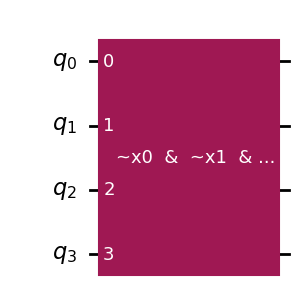

In [9]:
import sympy as sp
from sympy.logic import SOPform

# 1. 定义真值表（例如：2输入比特，真值表[1,1,0,1]）
input_bits = 3
truth_table = [1, 0, 0, 0, 0, 0, 0, 0]  # 对应x=00,01,10,11的输出

# 2. 用sympy将真值表转化为逻辑表达式（最小项之和）
variables = [sp.Symbol(f'x{i}') for i in range(input_bits)]
minterms = [i for i, val in enumerate(truth_table) if val == 1]  # f(x)=1的输入索引
expr = SOPform(variables, minterms)  # 生成"与或"表达式

# 3. 转换为Qiskit支持的表达式格式（替换符号为字符串）
logic_expr = str(expr).replace('&', ' & ').replace('|', ' | ').replace('~', '~')
print(logic_expr)
# 4. 生成Oracle

from qiskit.circuit.library import PhaseOracle, BitFlipOracleGate
from qiskit import QuantumCircuit

# oracle = PhaseOracle(logic_expr)
oracle = BitFlipOracleGate(logic_expr)

# 4. 创建量子电路
qc = QuantumCircuit(input_bits + 1)  # 输入比特 + 1 个辅助比特

# 5. 将 oracle 添加到电路中
qc.compose(oracle, inplace=True)

# 转换为"|x⟩|0⟩→|x⟩|f(x)⟩"形式的电路（PhaseOracle默认是相位翻转，需稍作调整）
# 方法：在辅助比特上添加H门，将相位翻转转化为振幅翻转（即目标态翻转）
# qc = QuantumCircuit(oracle.num_qubits, name="U_f")
# qc.append(oracle.to_gate(), range(oracle.num_qubits))
# # 若需要显式的输出比特（而非相位），可对辅助比特应用H门
# qc.h(oracle.num_qubits - 1)  # 最后一个比特为辅助比特

qc.draw("mpl")

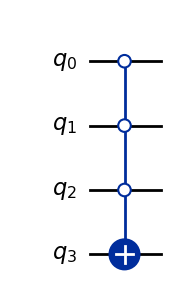

In [11]:
qc.decompose().draw("mpl")

In [13]:
qc.decompose().data[0]

CircuitInstruction(operation=Instruction(name='mcx_o0', num_qubits=4, num_clbits=0, params=[]), qubits=(<Qubit register=(4, "q"), index=0>, <Qubit register=(4, "q"), index=1>, <Qubit register=(4, "q"), index=2>, <Qubit register=(4, "q"), index=3>), clbits=())

In [6]:
oracle.count_ops()

OrderedDict([('x', 2), ('cz_o0', 1), ('z', 1)])